# **Arabic Sentiment Analysis using Classical Machine Learning**

## **1. Imports & Global Config**
Setting up all necessary libraries, resources, and global variables for preprocessing, feature extraction, visualization, and modeling.

### **1.1 Import Libraries**
- **Core:** `os`, `re`, `numpy`, `pandas` for data handling, manipulation, and regular expressions.  
- **Visualization:** `matplotlib.pyplot`, `seaborn`, `WordCloud` for plotting and visualizing distributions.  
- **NLP:** `nltk`, `ISRIStemmer` for Arabic text processing including stopwords removal and stemming.  
- **ML & Models:** `sklearn` modules for preprocessing, feature extraction, classical ML models, evaluation, and hyperparameter tuning.

In [1]:
# Core
import os
import re
import numpy as np
import pandas as pd
from wordcloud import WordCloud

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.dummy import DummyClassifier

# Models
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from scipy.sparse import hstack

### **1.2 Global Variables**
- **Labels:** Defines the sentiment classes: `POS`, `NEG`, `OBJ` (neutral).  
- **Stopwords & Negations:** Arabic stopwords for filtering common words, but negation words are preserved to retain sentiment context.  
- **Stemmer:** `ISRIStemmer` to reduce words to their root form.  
- **Emoji Handling:** Categorizes emojis into positive, negative, neutral, and replaces them with special tokens for modeling.  
- **Arabic Punctuation:** List of punctuation marks for text cleaning.

In [2]:
# Labels
LABELS = {"POS", "NEG", "OBJ", "NEUTRAL"}

# Arabic stopwords
nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))
negations = {"مش", "مو", "ما", "ليس", "لا", "لم", "لن", "بدون", "غير"}
arabic_stopwords -= negations

# Stemmer
stemmer = ISRIStemmer()

# Emoji dictionary
EMO_POS = " EMO_POS "
EMO_NEG = " EMO_NEG "
EMO_NEU = " EMO_NEU "

POS_EMOJIS = {
    "😂", "🤣", "😄", "😃", "😊", "😁", "😍", "🥰",
    "❤️", "💖", "💕", "👍", "👏", "🔥"
}

NEG_EMOJIS = {
    "😡", "🤬", "😠", "😢", "😭", "💔",
    "👎", "😞", "😤", "😰", "😨"
}

NEU_EMOJIS = {
    "😐", "😑", "😶", "🙄"
}

# Arabic punctuation
ARABIC_PUNCTUATION = "؟،؛ـ"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\batol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **2. Dataset Loading & Exploration**
**Purpose:** Load raw text data, convert it into a structured CSV, and explore initial content.
markdown
Copy code

### **2.1 Dataset Loading & Conversion to CSV**
- Reads a tab-separated text file containing tweets and sentiment labels.  
- Converts "NEUTRAL" labels to "OBJ" for consistency.  
- Saves processed data as CSV for easier handling in Python.

In [3]:
# Load TXT dataset and convert to CSV
def convert_to_csv(file_name="Arabic-Tweets_Dataset.txt"):
    data = []
    with open(file_name, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit("\t", 1)
            if len(parts) == 2 and parts[1] in LABELS:
                text, label = parts
                data.append([text, label])
            else:
                print("Skipped malformed line:", line)
    df = pd.DataFrame(data, columns=["text", "label"])
    df["label"] = df["label"].replace({"NEUTRAL": "OBJ"})
    df.to_csv("Arabic-Tweets_Dataset.csv", index=False, encoding="utf-8-sig")
    return df

df = convert_to_csv()
df.head()

,text,label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ


### **2.2 Make a copy of the Data for Safety**
- Keeps a copy of the raw dataset untouched to allow safe preprocessing experimentation.

In [4]:
df_raw = df.copy()   # Keep this untouched
df = df_raw.copy()   # Work on this copy for preprocessing & feature extraction

## **3. Preprocessing**
**Purpose:** Clean, normalize, and standardize Arabic text for model input. This reduces noise and improves feature quality.
markdown
Copy code


### **3.1 Normalize Arabic Letters**
Unifies variants of the same letters (e.g., `أ`, `إ` → `ا`). 

In [5]:
# Arabic text normalization
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    return text

### **3.2 Remove Elongation**
Collapses repeated characters (e.g., `ممتااااز` → `ممتاز`). 

In [6]:
def remove_elongation(text):
    return re.sub(r'(.)\1+', r'\1', text)

### **3.3 Remove URLs, HTML tags, Numbers & Special Characters**
Removes URLs, HTML tags, numbers, and special characters (except hashtags).  

In [7]:
# Remove URLs, HTML tags, and numbers
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    text = re.sub(r"<.*?>", '', text)  # remove HTML tags
    text = re.sub(r"\d+", '', text)    # remove numbers
    text = re.sub(r"[^\w\s#]", '', text)  # remove other punctuation except hashtags
    return text

### **3.4 Replace Emojis**
Converts emojis into sentiment tokens (`EMO_POS`, `EMO_NEG`, `EMO_NEU`).  

In [8]:
def replace_emojis(text):
    result = []
    for ch in text:
        if ch in POS_EMOJIS:
            result.append(EMO_POS)
        elif ch in NEG_EMOJIS:
            result.append(EMO_NEG)
        elif ch in NEU_EMOJIS:
            result.append(EMO_NEU)
        else:
            result.append(ch)
    return "".join(result)

### **3.5 Handle Negation**
Modifies words following negation terms to preserve reversed meaning (`مش جميل` → `NOT_جميل`).  

In [9]:
def handle_negation(text):
    tokens = text.split()
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations and i+1 < len(tokens):
            result.append("NOT_" + tokens[i+1])
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return " ".join(result)

### **3.6 Remove Stopwords**
Filters out common words that carry little sentiment meaning.

In [10]:
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    return " ".join(words)

### **3.7 Stemming**
Converts words to their root form to reduce lexical variation.

In [11]:
def stem_text(text):
    words = text.split()
    return " ".join([stemmer.stem(w) for w in words])

### **3.8 Apply Preprocessing**
- Combines all the above steps into one function applied to all tweets.

In [12]:
def preprocess_text(text):
    # Normalize
    text = normalize_arabic(text)
    
    # Remove elongation
    text = remove_elongation(text)
    
    # Clean text (remove URLs, HTML, numbers, punctuation)
    text = clean_text(text)
    
    # Keep hashtags as separate words
    text = re.sub(r"#(\w+)", r"\1", text)
    
    # Replace emojis with sentiment tokens
    text = replace_emojis(text)
    
    # Handle negation across multiple words (2 words after negation)
    tokens = text.split()
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations:
            j = i + 1
            while j < min(i+3, len(tokens)):
                tokens[j] = "NOT_" + tokens[j]
                j += 1
            result.append(tokens[i])
            i += 1
        else:
            result.append(tokens[i])
            i += 1
    text = " ".join(result)
    
    # Remove stopwords
    text = remove_stopwords(text)
    
    # Stemming
    text = stem_text(text)
    
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)
df.head()

,text,label,cleaned_text
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ,قال ريس محكمه_الدستوريه تظر قال ريس_القضاء سود
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS,اهن دكتور حمد جمل دين قيد حزب مصر نسب صدر اول ريت
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG,ردع سقو بمر مرهاخر رسل عصم عري الي شنط شي قرف
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ,حريه_والعداله شهد الن ليله_الاتحاديه اول يلم ق...
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ,ولد اقل خطر حشش تضح اقل مل اله وكل تعط حضر فسق...


## **4. Exploratory Data Analysis (EDA)**
**Purpose:** Understand the dataset’s characteristics and distribution before modeling.

#### **4.1 Explore Class Distribution**
- Visualizes how many tweets belong to each sentiment category.

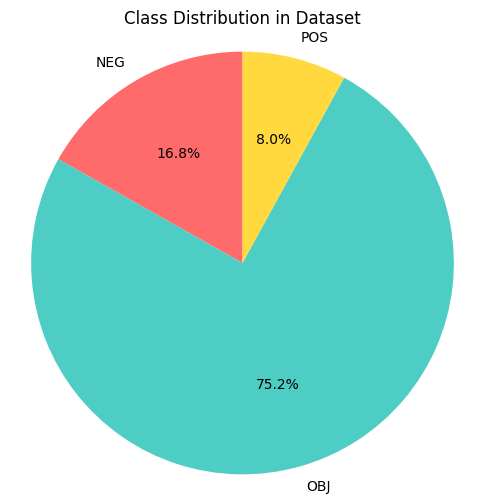

In [13]:
y = df["label"]

# Count number of samples per class
counts = y.value_counts()[["NEG", "OBJ", "POS"]]

plt.figure(figsize=(6,6))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#FF6B6B','#4ECDC4','#FFD93D']
)
plt.title("Class Distribution in Dataset")
plt.axis('equal')  # Makes the pie circular
plt.show()


### **4.2 Text length distribution per sentiment**
- Explores tweet length across sentiments to identify patterns (e.g., negative tweets may be shorter).

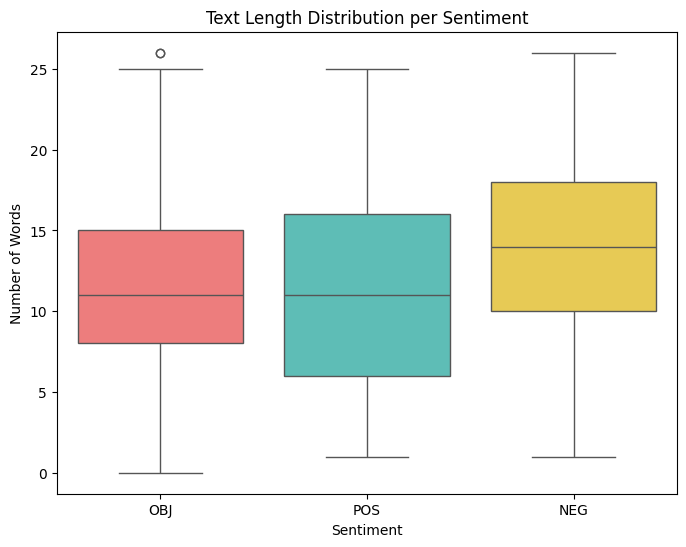

In [14]:
# Add new column for text length
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='text_length', data=df, hue='label', palette=['#FF6B6B','#4ECDC4','#FFD93D'])
plt.title("Text Length Distribution per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()


#### **4.3 Negation counts per class**
- Counts negation usage per sentiment to see how negation patterns correlate with sentiment.

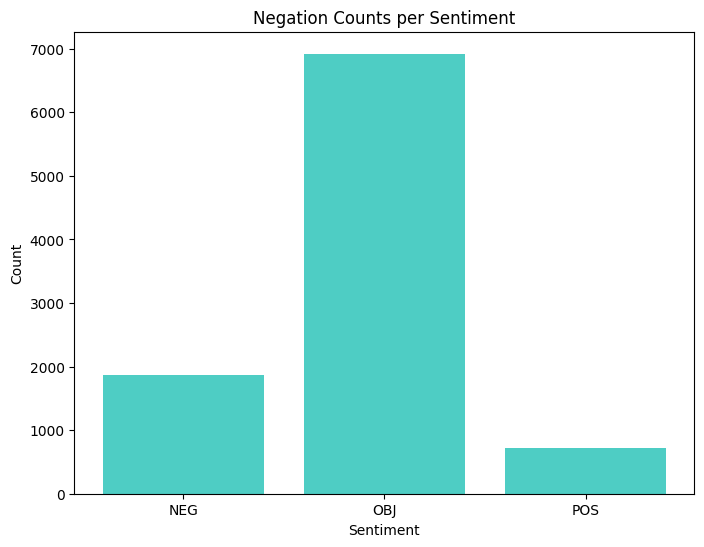

In [15]:
# Negation count
df["neg_count"] = df["cleaned_text"].apply(lambda x: sum(x.count(n) for n in negations))

# Group negation counts by sentiment
negation_stats = df.groupby("label")["neg_count"].sum()

# 5. Plot negation counts
plt.figure(figsize=(8,6))
plt.bar(negation_stats.index, negation_stats.values.astype(int), color="#4ECDC4")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Negation Counts per Sentiment")
plt.show()


## **5. Feature Extraction**
**Purpose:** Transform text into numerical features for ML models, combining general and Arabic-specific features.

We extract both:
1. **Text-based features** using TF(Term Frequency inside one tweet)-IDF(Inverse Document Frequency meaning in the whole document) (max 2000 features, unigrams and bigrams).
2. **Handcrafted features** specific to Arabic:
   - Negation count
   - Dialect words presence
   - Emoji features

These are combined using `hstack` into a single feature matrix `X`.


### **5.1 TF-IDF Representation**
- Converts text into vector form capturing term frequency and inverse document frequency.  
- Uses unigrams & bigrams with a maximum of 20,000 features.

In [16]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # VERY IMPORTANT
    max_features=5000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])

### **5.2 Arabic-Specific Feature Functions**
- **Negation Count:** Number of negation terms in a tweet.  
- **Dialect Words Presence:** Flags tweets containing specific dialect words.  
- **Emoji Features:** Flags presence of positive/negative emojis.

In [17]:
def negation_count(text): 
    return sum(text.count(n) for n in negations)
def dialect_feature(text): 
    return int(any(w in text for w in ["مش","مو","شو","ليش","هيك"]))
def emoji_features(text):
    return pd.Series({"has_positive_emoji": int("EMO_POS" in text),
                      "has_negative_emoji": int("EMO_NEG" in text)})
df["neg_count"] = df["cleaned_text"].apply(negation_count)
df["dialect"] = df["cleaned_text"].apply(dialect_feature)
emoji_df = df["cleaned_text"].apply(emoji_features)
df = pd.concat([df, emoji_df], axis=1)

handcrafted = df[["neg_count","dialect","has_positive_emoji","has_negative_emoji"]].values

### **5.4 Combine Features**
- Merges TF-IDF vectors with handcrafted Arabic-specific features using `hstack`.

In [18]:
# Combine TF-IDF, and handcrafted features
X = hstack([X_tfidf, handcrafted])
y = df["label"]

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (10006, 5004)


## **6. Dataset Split**
**Purpose:** Create separate datasets for training, validation, and testing while preserving class distribution.

We split the data into:
- 60% training
- 20% validation
- 20% testing

We use stratified splitting to maintain the class distribution across all sets.

### **6.1 Main Split**
- 60% training, 20% validation, 20% testing using stratified splits.


In [19]:
# Split into 60/40, 60% training, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Split the 40% temp into 20% tesing, 20% validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

### **6.2 Naïve Bayes Specific Split**
- Naïve Bayes uses only TF-IDF features, so a separate split is maintained for TF-IDF inputs.

In [20]:
X_nb_train, X_nb_temp, y_nb_train, y_nb_temp = train_test_split(
    X_tfidf, y, test_size=0.4, stratify=y, random_state=42
)
X_nb_val, X_nb_test, y_nb_val, y_nb_test = train_test_split(
    X_nb_temp, y_nb_temp, test_size=0.5, stratify=y_nb_temp, random_state=42
)

## **7. Model Training & Validation**

**Purpose:** Train multiple classical ML models and a neural network on the preprocessed features and evaluate performance.

#### Decision Tree
We use a Decision Tree Classifier to model non-linear relationships in the features.  
- Max depth = 10 → controls tree size to reduce overfitting.  
- Min samples split = 2 → minimum samples required to split a node.  
- Min samples leaf = 1 → minimum samples required at a leaf node.  
- Class weights are used to address class imbalance.  
- Feature set: combined features (TF-IDF + handcrafted features).  

#### Random Forest
We use a Random Forest Classifier, an ensemble of decision trees for better generalization.  
- Number of trees (n_estimators) = 100.  
- Max depth = 10, Min samples split = 2, Min samples leaf = 1.  
- Class weights are applied to handle imbalanced classes.  
- Feature set: combined features (TF-IDF + handcrafted features).  

#### Naïve Bayes
We use MultinomialNB, which works well for discrete features like TF-IDF.  
- Alpha = 0.01 → Laplace smoothing to avoid zero probabilities.  
- Fit prior = True → adjusts prior probabilities according to class distribution.  
- Feature set: TF-IDF only.  

#### Neural Network (MLP)
We use a feed-forward multilayer perceptron:  
- Hidden layers: (128, 64) → two layers with decreasing size for hierarchical feature abstraction.  
- Learning rate = 0.001, optimizer = Adam.  
- L2 regularization (alpha = 0.0001) to reduce overfitting.  
- Max iterations = 80 → limits training time; early stopping can be added.  
- Feature set: combined features (TF-IDF + handcrafted features).  
- Class weights are used to improve performance on minority classes.

#### **Compute class weights**
Addresses imbalanced classes to improve minority class predictions.

In [21]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_array))
print("Class weights:", class_weight_dict)

Class weights: {'NEG': np.float64(1.9811881188118812), 'OBJ': np.float64(0.4433857744294261), 'POS': np.float64(4.16875)}


#### **Compute Macro F1 Scorer**
Metric for grid search optimization focusing on balanced performance across classes.

In [22]:
f1_macro_scorer = make_scorer(
    f1_score,
    average="macro",
    labels=["NEG", "OBJ", "POS"],
    zero_division=0
)

#### **Model Validation Function**

In [23]:
def evaluate_on_validation(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    print(f"\n--- {name} (Validation) ---")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=["NEG","OBJ","POS"], zero_division=0))

#### **GridSearchCV Function**

In [24]:
def run_grid_search(model, param_grid, X_train, y_train, cv_splits=3):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid,
        scoring=f1_macro_scorer,
        cv=cv,
        verbose=2,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"Best params for {model.__class__.__name__}: {grid.best_params_}\n")
    return grid.best_estimator_

### **7.0 Dummy Model** 

In [25]:
from sklearn.dummy import DummyClassifier

# Baseline model: always predicts the most frequent class (OBJ)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_baseline_val = baseline.predict(X_val)

evaluate_on_validation("Baseline (Majority Class)", baseline, X_val, y_val)

y_pred_baseline_test = baseline.predict(X_test)


--- Baseline (Majority Class) (Validation) ---
Accuracy: 0.7521239380309845
              precision    recall  f1-score   support

         NEG       0.00      0.00      0.00       337
         OBJ       0.75      1.00      0.86      1505
         POS       0.00      0.00      0.00       159

    accuracy                           0.75      2001
   macro avg       0.25      0.33      0.29      2001
weighted avg       0.57      0.75      0.65      2001



### **7.1 Decision Tree**

In [26]:
# Initial DT Model
dt = DecisionTreeClassifier( max_depth=20, min_samples_split=5, class_weight="balanced", random_state=42 ) 
dt.fit(X_train, y_train) 

# Validation evaluation 
y_pred_dt = dt.predict(X_val) 
evaluate_on_validation("Decision Tree", dt, X_val, y_val) 


--- Decision Tree (Validation) ---
Accuracy: 0.6966516741629185
              precision    recall  f1-score   support

         NEG       0.37      0.21      0.27       337
         OBJ       0.78      0.85      0.81      1505
         POS       0.25      0.24      0.24       159

    accuracy                           0.70      2001
   macro avg       0.46      0.43      0.44      2001
weighted avg       0.67      0.70      0.68      2001



In [27]:
dt_params = {
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}
best_dt = run_grid_search(
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    dt_params,
    X_train, y_train
)

# Validation evaluation 
y_pred_dt_val = best_dt.predict(X_val) 
evaluate_on_validation("Decision Tree", best_dt, X_val, y_val) 
# Test evaluation metric
y_pred_dt_test = best_dt.predict(X_test) 

Fitting 3 folds for each of 27 candidates, totalling 81 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best params for DecisionTreeClassifier: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


--- Decision Tree (Validation) ---
Accuracy: 0.7081459270364817
              precision    recall  f1-score   support

         NEG       0.34      0.14      0.19       337
         OBJ       0.77      0.89      0.82      1505
         POS       0.28      0.21      0.24       159

    accuracy                           0.71      2001
   macro avg       0.46      0.41      0.42      2001
weighted avg       0.66      0.71      0.67      2001



### **7.2 Random Forest**

In [28]:
# Initial RF Model
rf = RandomForestClassifier( n_estimators=200, max_depth=20, min_samples_split=5, class_weight="balanced", random_state=42, n_jobs=-1 ) 
rf.fit(X_train, y_train) 

# Validation evaluation
y_pred_rf = rf.predict(X_val)
evaluate_on_validation("Random Forest", rf, X_val, y_val)


--- Random Forest (Validation) ---
Accuracy: 0.6591704147926037
              precision    recall  f1-score   support

         NEG       0.35      0.46      0.40       337
         OBJ       0.81      0.74      0.78      1505
         POS       0.26      0.30      0.28       159

    accuracy                           0.66      2001
   macro avg       0.47      0.50      0.48      2001
weighted avg       0.69      0.66      0.67      2001



In [29]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_rf = run_grid_search(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    rf_params,
    X_train, y_train
)

# Validation evaluation
y_pred_rf_val = best_rf.predict(X_val)
evaluate_on_validation("Random Forest", best_rf, X_val, y_val)

# Test evaluation metric
y_pred_rf_test = best_rf.predict(X_test)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


Best params for RandomForestClassifier: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


--- Random Forest (Validation) ---
Accuracy: 0.6331834082958521
              precision    recall  f1-score   support

         NEG       0.33      0.50      0.40       337
         OBJ       0.82      0.70      0.75      1505
         POS       0.25      0.33      0.28       159

    accuracy                           0.63      2001
   macro avg       0.46      0.51      0.48      2001
weighted avg       0.69      0.63      0.65      2001



### **7.3 Naïve Bayes**

In [30]:
# Initial NB Model
# Naïve Bayes — TF-IDF ONLY
nb = MultinomialNB(alpha=0.5)
nb.fit(X_nb_train, y_nb_train)

# Validation evaluation
y_pred_nb = nb.predict(X_nb_val)
evaluate_on_validation("Naïve Bayes", nb, X_nb_val, y_nb_val)


--- Naïve Bayes (Validation) ---
Accuracy: 0.7596201899050474
              precision    recall  f1-score   support

         NEG       0.63      0.09      0.15       337
         OBJ       0.76      0.99      0.86      1505
         POS       1.00      0.02      0.04       159

    accuracy                           0.76      2001
   macro avg       0.80      0.36      0.35      2001
weighted avg       0.76      0.76      0.68      2001



In [31]:
nb_params = {
    "alpha": [0.01, 0.1, 0.5, 1.0],
    "fit_prior": [True, False]
}
best_nb = run_grid_search(
    MultinomialNB(),
    nb_params,
    X_nb_train, y_nb_train
)

# Validation evaluation
y_pred_nb_val = best_nb.predict(X_nb_val)
evaluate_on_validation("Naïve Bayes", best_nb, X_nb_val, y_nb_val)

# Test evaluation metric
y_pred_nb_test = best_nb.predict(X_nb_test)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params for MultinomialNB: {'alpha': 0.01, 'fit_prior': True}


--- Naïve Bayes (Validation) ---
Accuracy: 0.7406296851574213
              precision    recall  f1-score   support

         NEG       0.41      0.19      0.26       337
         OBJ       0.78      0.93      0.85      1505
         POS       0.40      0.09      0.14       159

    accuracy                           0.74      2001
   macro avg       0.53      0.40      0.42      2001
weighted avg       0.68      0.74      0.69      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


### **7.4 Neural Network**

In [32]:
scaler = StandardScaler(with_mean=False)  # sparse matrices
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=80,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)

# Validation evaluation
y_pred_mlp_val = best_mlp.predict(X_val_scaled)
evaluate_on_validation("MLP Neural Network", best_mlp, X_val_scaled, y_val)

# Test evaluation metric
y_pred_mlp_test = best_mlp.predict(X_test_scaled)


--- MLP Neural Network (Validation) ---
Accuracy: 0.7091454272863568
              precision    recall  f1-score   support

         NEG       0.34      0.24      0.28       337
         OBJ       0.78      0.87      0.83      1505
         POS       0.30      0.18      0.22       159

    accuracy                           0.71      2001
   macro avg       0.48      0.43      0.44      2001
weighted avg       0.67      0.71      0.69      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


### **Results Table**

In [33]:
# Make a dictionary with initial and tuned predictions
models_val_init = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Naïve Bayes": y_pred_nb,
    "MLP NN": y_pred_mlp_val
}

models_val_tuned = {
    "Decision Tree": y_pred_dt_val,
    "Random Forest": y_pred_rf_val,
    "Naïve Bayes": y_pred_nb_val,
    "MLP NN": y_pred_mlp_val
}

# Compute results for both initial and tuned models
results_combined = []

# Baseline first
acc_baseline = accuracy_score(y_val, y_pred_baseline_val)
f1_baseline = f1_score(y_val, y_pred_baseline_val, average='macro', zero_division=0)
results_combined.append({
    "Model": "Baseline",
    "Macro F1 (Init)": round(f1_baseline, 3),
    "Macro F1 (Tuned)": round(f1_baseline, 3),
    "Accuracy (Init)": round(acc_baseline, 3),
    "Accuracy (Tuned)": round(acc_baseline, 3)
})

# Loop through models
for model_name in models_val_init.keys():
    y_init = models_val_init[model_name]
    y_tuned = models_val_tuned[model_name]
    
    results_combined.append({
        "Model": model_name,
        "Macro F1 (Init)": round(f1_score(y_val, y_init, average='macro', zero_division=0), 3),
        "Macro F1 (Tuned)": round(f1_score(y_val, y_tuned, average='macro', zero_division=0), 3),
        "Accuracy (Init)": round(accuracy_score(y_val, y_init), 3),
        "Accuracy (Tuned)": round(accuracy_score(y_val, y_tuned), 3)
    })

# Convert to DataFrame
df_results_combined = pd.DataFrame(results_combined)
print(df_results_combined)

           Model  Macro F1 (Init)  Macro F1 (Tuned)  Accuracy (Init)  \
0       Baseline            0.286             0.286            0.752   
1  Decision Tree            0.442             0.420            0.697   
2  Random Forest            0.483             0.477            0.659   
3    Naïve Bayes            0.350             0.418            0.760   
4         MLP NN            0.444             0.444            0.709   

   Accuracy (Tuned)  
0             0.752  
1             0.708  
2             0.633  
3             0.741  
4             0.709  


## **8. Model Evaluation**
**Purpose:** Assess the trained models using multiple metrics to understand their real-world performance.

We evaluate models using three metrics:
- **Accuracy:** Overall correctness of predictions.  
- **Macro F1 Score:** Measures performance across all classes equally (main metric for imbalanced classes).  
- **Weighted F1 Score:** Accounts for class imbalance.  
- **Classification Report:** Precision, recall, F1-score per class.  
- **Confusion Matrix:** Visual representation of true vs predicted labels.


#### **Model Evaluation Function**

In [34]:
def evaluate_on_test(model_name, y_true, y_pred):
    print("=" * 60)
    print(f"{model_name} — Test Set Evaluation")
    print("=" * 60)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 Macro (main) : {f1_macro:.4f}")
    print(f"F1 Weighted     : {f1_weighted:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=["NEG","OBJ","POS"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NEG","OBJ","POS"], yticklabels=["NEG","OBJ","POS"])
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

### **8.0 Evaluate Baseline Model**

Baseline Model — Test Set Evaluation
Accuracy        : 0.7517
F1 Macro (main) : 0.2861
F1 Weighted     : 0.6452

Classification Report:
              precision    recall  f1-score   support

         NEG     0.0000    0.0000    0.0000       337
         OBJ     0.7517    1.0000    0.8583      1505
         POS     0.0000    0.0000    0.0000       160

    accuracy                         0.7517      2002
   macro avg     0.2506    0.3333    0.2861      2002
weighted avg     0.5651    0.7517    0.6452      2002

Confusion Matrix:
[[   0  337    0]
 [   0 1505    0]
 [   0  160    0]]


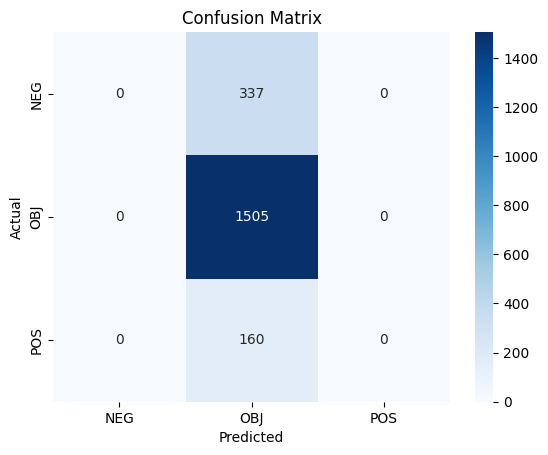

In [35]:
evaluate_on_test("Baseline Model", y_test, y_pred_baseline_test)

### **8.1 Evaluate Decision Tree**

Decision Tree — Test Set Evaluation
Accuracy        : 0.7088
F1 Macro (main) : 0.4305
F1 Weighted     : 0.6784

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3694    0.1721    0.2348       337
         OBJ     0.7756    0.8817    0.8252      1505
         POS     0.2537    0.2125    0.2313       160

    accuracy                         0.7088      2002
   macro avg     0.4662    0.4221    0.4305      2002
weighted avg     0.6655    0.7088    0.6784      2002

Confusion Matrix:
[[  58  266   13]
 [  91 1327   87]
 [   8  118   34]]


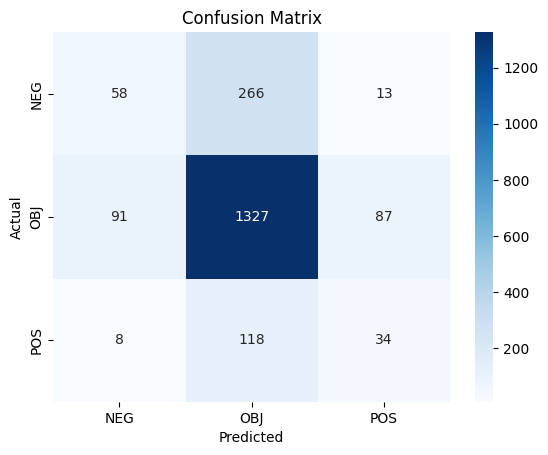

In [36]:
evaluate_on_test("Decision Tree", y_test, y_pred_dt_test)

### **8.2 Evaluate Random Forest**

Random Forest — Test Set Evaluation
Accuracy        : 0.6174
F1 Macro (main) : 0.4741
F1 Weighted     : 0.6433

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3277    0.5163    0.4009       337
         OBJ     0.8196    0.6671    0.7355      1505
         POS     0.2358    0.3625    0.2857       160

    accuracy                         0.6174      2002
   macro avg     0.4610    0.5153    0.4741      2002
weighted avg     0.6901    0.6174    0.6433      2002

Confusion Matrix:
[[ 174  139   24]
 [ 337 1004  164]
 [  20   82   58]]


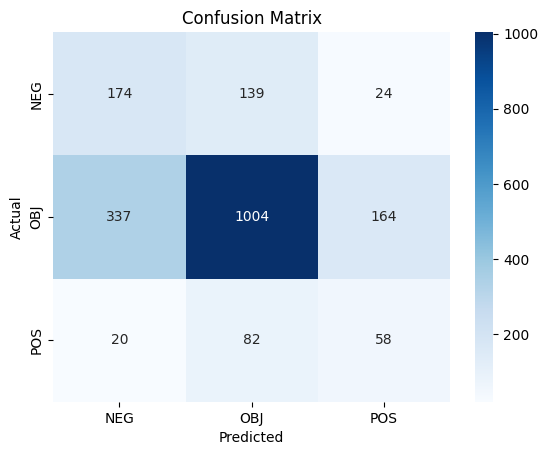

In [37]:
evaluate_on_test("Random Forest", y_test, y_pred_rf_test)

### **8.3 Evaluate Naïve Bayes**

Naïve Bayes — Test Set Evaluation
Accuracy        : 0.7363
F1 Macro (main) : 0.4214
F1 Weighted     : 0.6904

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3987    0.1869    0.2545       337
         OBJ     0.7749    0.9262    0.8438      1505
         POS     0.3778    0.1062    0.1659       160

    accuracy                         0.7363      2002
   macro avg     0.5171    0.4065    0.4214      2002
weighted avg     0.6798    0.7363    0.6904      2002

Confusion Matrix:
[[  63  270    4]
 [  87 1394   24]
 [   8  135   17]]


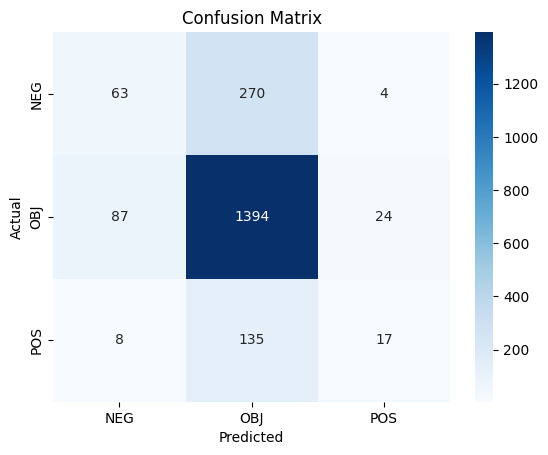

In [38]:
evaluate_on_test("Naïve Bayes", y_nb_test, y_pred_nb_test)

### **8.4 Evaluate Neural Network**

MLP Neural Network — Test Set Evaluation
Accuracy        : 0.7053
F1 Macro (main) : 0.4532
F1 Weighted     : 0.6876

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3658    0.2789    0.3165       337
         OBJ     0.7873    0.8558    0.8201      1505
         POS     0.2752    0.1875    0.2230       160

    accuracy                         0.7053      2002
   macro avg     0.4761    0.4407    0.4532      2002
weighted avg     0.6754    0.7053    0.6876      2002

Confusion Matrix:
[[  94  229   14]
 [ 152 1288   65]
 [  11  119   30]]


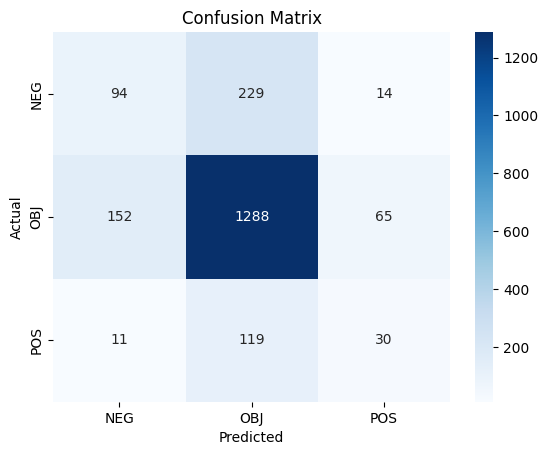

In [39]:
evaluate_on_test("MLP Neural Network", y_test, y_pred_mlp_test)

### **Results Table**
- Clearly compares all models on `Accuracy` and `Macro F1` to determine the best-performing approach for Arabic sentiment analysis.

In [40]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Correct predictions
predictions = {
    "Baseline": {
        "Initial": y_pred_baseline_val,
        "Tuned": y_pred_baseline_val,
        "Test": y_pred_baseline_test
    },
    "Decision Tree": {
        "Initial": y_pred_dt,
        "Tuned": y_pred_dt_val,
        "Test": y_pred_dt_test
    },
    "Random Forest": {
        "Initial": y_pred_rf,
        "Tuned": y_pred_rf_val,
        "Test": y_pred_rf_test
    },
    "Naïve Bayes": {
        "Initial": y_pred_nb,
        "Tuned": y_pred_nb_val,
        "Test": y_pred_nb_test
    },
    "MLP Neural Network": {
        "Initial": y_pred_mlp_val,   # only have one validation prediction
        "Tuned": y_pred_mlp_val,
        "Test": y_pred_mlp_test
    }
}

# Create results list
results = []
for model_name, stages in predictions.items():
    for stage_name, y_pred in stages.items():
        # Make sure to use correct labels: validation predictions with y_val, test predictions with y_test
        y_true = y_val if stage_name in ["Initial", "Tuned"] and model_name != "Baseline" else y_test
        if model_name == "Baseline" and stage_name != "Test":
            y_true = y_val
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        results.append({
            "Model": model_name,
            "Stage": stage_name,
            "Accuracy": round(acc, 3),
            "Macro F1": round(f1_macro, 3)
        })

# Convert to DataFrame and pivot for clarity
df_results_combined = pd.DataFrame(results)
df_results_combined = df_results_combined.pivot(index="Model", columns="Stage", values=["Macro F1", "Accuracy"])
df_results_combined = df_results_combined.sort_index()
print(df_results_combined)

                   Macro F1               Accuracy              
Stage               Initial   Test  Tuned  Initial   Test  Tuned
Model                                                           
Baseline              0.286  0.286  0.286    0.752  0.752  0.752
Decision Tree         0.442  0.430  0.420    0.697  0.709  0.708
MLP Neural Network    0.444  0.453  0.444    0.709  0.705  0.709
Naïve Bayes           0.350  0.421  0.418    0.760  0.736  0.741
Random Forest         0.483  0.474  0.477    0.659  0.617  0.633
